# Día 3 — Análisis de correlación

**Notebook:** `02_correlacion.ipynb`
**Responsables:** Guillermo, Emiliano
**Materia:** Tópicos Selectos de Ciencias de la Ingeniería 3 (UANL, FIME)

En este notebook le seguimos la pista a lo que salió en el análisis exploratorio del Día 2. Ahí, nada más con las gráficas, ya se notaba que fumar era lo que más parecía mover los cargos médicos. Lo que toca ahora es dejar de "verlo" y pasar a medirlo con un número, y para eso sirve la correlación: nos dice qué tan relacionadas están dos variables y de qué tamaño es esa relación.

Partimos del dataset ya limpio del Día 1 (`00_setup.ipynb`) y trabajamos sobre una copia numérica que llamamos `df_numerico`, porque la correlación nada más funciona con números.

## 0. Preparación de los datos

Antes de calcular nada tenemos que dejar todo en formato numérico. El detalle es que tres variables (`sex`, `smoker` y `region`) vienen como texto, y la correlación no sabe qué hacer con palabras. Así que las convertimos:

- `sex` y `smoker` son de dos categorías, entonces las pasamos directo a 0 y 1.
- `region` tiene cuatro categorías, así que usamos codificación *one-hot* con `pd.get_dummies`, que crea una columna por región. Le ponemos `drop_first=True` para quitar una de esas columnas y no caer en la "trampa de las variables dummy", que es cuando una columna se puede deducir de las otras y termina metiendo información repetida.

Todo eso lo guardamos en `df_numerico` y dejamos el dataset original sin tocar.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Cargamos el dataset y le quitamos el duplicado, igual que en el Dia 1
df = pd.read_csv("../data/insurance.csv").drop_duplicates().reset_index(drop=True)

# Copia numerica para poder correlacionar
df_numerico = df.copy()
df_numerico["sex"] = df_numerico["sex"].map({"male": 0, "female": 1})
df_numerico["smoker"] = df_numerico["smoker"].map({"no": 0, "yes": 1})
df_numerico = pd.get_dummies(df_numerico, columns=["region"], drop_first=True, dtype=int)

print("df_numerico:", df_numerico.shape[0], "filas x", df_numerico.shape[1], "columnas")
df_numerico.head()

df_numerico: 1337 filas x 9 columnas


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


## 1. Matriz de correlación (Pearson)

La correlación se resume en un número entre -1 y 1. Si anda cerca de 1, las dos variables suben juntas; si anda cerca de -1, cuando una sube la otra baja; y si está por el 0, no hay relación (al menos no una relación lineal). El coeficiente más usado es el de Pearson, que por dentro es la covarianza (qué tanto se mueven juntas dos variables) pero dividida entre sus desviaciones estándar, para que quede acotado entre -1 y 1.

Lo sacamos para todas las variables de un jalón con `.corr()` y lo mostramos como mapa de calor (*heatmap*), que básicamente le pone un color a cada número para leerlo más rápido.

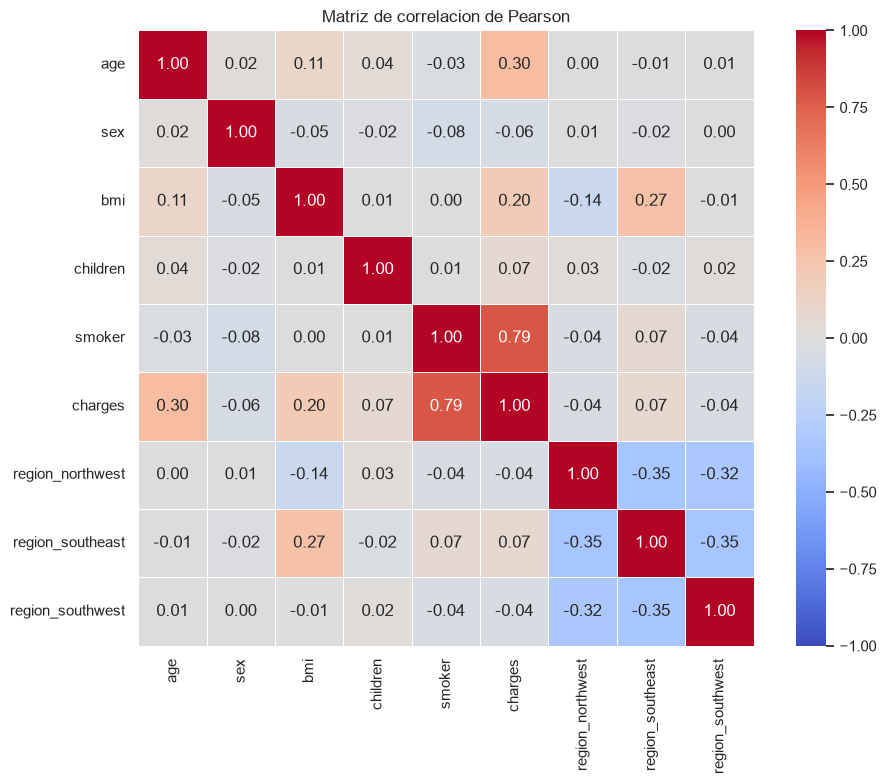

In [2]:
corr_pearson = df_numerico.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matriz de correlacion de Pearson")
plt.tight_layout()
plt.savefig("../reports/figures/d3_heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [3]:
# Nos quedamos con la columna de charges, que es lo que queremos explicar
ranking = corr_pearson["charges"].sort_values(ascending=False)
print(ranking.round(3))

charges             1.000
smoker              0.787
age                 0.298
bmi                 0.198
region_southeast    0.074
children            0.067
region_northwest   -0.039
region_southwest   -0.044
sex                -0.058
Name: charges, dtype: float64


### ¿Qué nos dice el heatmap?

La columna que nos importa es la de `charges`, porque es nuestra variable dependiente (lo que queremos explicar); el resto son las variables independientes. Ordenando de mayor a menor, lo que más resalta es `smoker` con 0.79. Eso ya es una correlación fuerte: como referencia, se suele tomar como débil por debajo de 0.4, moderada entre 0.4 y 0.7, y fuerte arriba de 0.7 (Schober et al., 2018). O sea, ser fumador es de lejos lo que más se relaciona con pagar cargos altos.

Luego vienen `age` (0.30) y `bmi` (0.20), con una relación entre débil y moderada. El resto (`children`, `sex` y las regiones) andan casi en cero, así que por sí solas casi no explican los cargos.

Hay que tener cuidado con una cosa: `charges` está sesgada (en el Día 2 vimos que tiene una cola larga hacia la derecha), y Pearson es sensible a eso porque asume una relación lineal. Por eso conviene revisar también una correlación que no dependa tanto de la forma de los datos, y ahí entra Spearman.

## 2. Correlación de Spearman

Spearman hace lo mismo que Pearson pero, en lugar de usar los valores tal cual, usa el orden (el ranking) de los datos. Eso lo hace más aguantador cuando hay valores atípicos o cuando la relación no es una recta perfecta pero sí va siempre en la misma dirección (a eso se le llama relación monótona). Como `charges` tiene outliers y está sesgada, vale la pena compararlo con Pearson.

In [4]:
corr_spearman = df_numerico.corr(method="spearman")
print(corr_spearman["charges"].sort_values(ascending=False).round(3))

charges             1.000
smoker              0.664
age                 0.534
children            0.132
bmi                 0.120
region_southeast    0.017
sex                -0.011
region_northwest   -0.020
region_southwest   -0.043
Name: charges, dtype: float64


### Comparando Pearson y Spearman

Aquí pasa algo que se nos hizo interesante. `smoker` sigue arriba, aunque baja un poco a 0.66 (es normal que cambie porque es una variable de nada más dos valores). Pero `age` salta de 0.30 en Pearson a 0.53 en Spearman, casi el doble.

Esto cuadra con los scatterplots del Día 2: los cargos sí suben con la edad, pero no en una línea recta perfecta, sino en "bandas". Pearson, que anda buscando líneas rectas, se queda corto midiendo esa relación; Spearman, que solo mira el orden, la capta mejor. En pocas palabras, la edad pesa más de lo que Pearson dejaba ver, nada más que su relación con los cargos no es del todo lineal.

## 3. Un detalle sobre `smoker`: correlación punto-biserial

`smoker` no es una variable numérica de verdad, es de dos categorías (fuma o no fuma) que nosotros pasamos a 1 y 0. Cuando calculas la correlación de Pearson entre una variable así (dicotómica) y una continua como `charges`, técnicamente estás calculando lo que se llama correlación punto-biserial. Lo bueno es que da exactamente el mismo número que Pearson y se interpreta igual (Statistics By Jim, s.f.).

La calculamos aparte con scipy para de paso sacar el p-value, que nos dice qué tan probable sería ver esta relación de pura casualidad si en realidad no existiera.

In [5]:
r_pb, p_pb = stats.pointbiserialr(df_numerico["smoker"], df_numerico["charges"])
print(f"Correlacion punto-biserial (smoker vs charges): r = {r_pb:.3f}")
print(f"p-value: {p_pb:.3e}")

Correlacion punto-biserial (smoker vs charges): r = 0.787
p-value: 1.407e-282


El coeficiente sale 0.79, igual que en Pearson como esperábamos, y el p-value es prácticamente cero. Ese p-value tan chiquito quiere decir que la relación entre fumar y los cargos es estadísticamente significativa, o sea que no es casualidad. Como referencia se usa el umbral de 0.05, y nosotros estamos muchísimo por debajo.

## 4. Comparación de `charges` por grupo

Los números de correlación están bien, pero se entienden mejor si vemos cómo cambian los cargos según el grupo. Para eso usamos diagramas de caja (*boxplots*), que muestran la mediana, el rango donde cae la mitad de los datos (el rango intercuartílico) y los valores atípicos como puntos sueltos. Comparamos `charges` según `smoker`, `sex` y `region`.

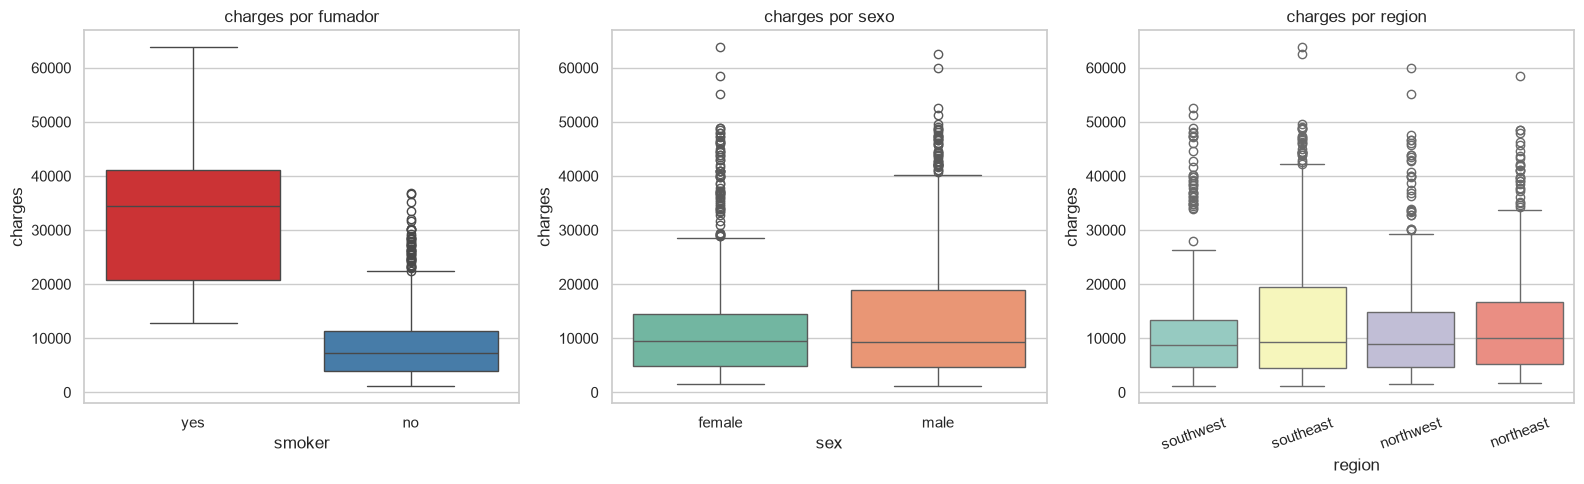

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0],
            hue="smoker", palette="Set1", legend=False)
axes[0].set_title("charges por fumador")

sns.boxplot(data=df, x="sex", y="charges", ax=axes[1],
            hue="sex", palette="Set2", legend=False)
axes[1].set_title("charges por sexo")

sns.boxplot(data=df, x="region", y="charges", ax=axes[2],
            hue="region", palette="Set3", legend=False)
axes[2].set_title("charges por region")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../reports/figures/d3_charges_por_grupo.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Respaldo numerico: gasto promedio por grupo
print("Promedio de charges por grupo:\n")
print("Por fumador:\n", df.groupby("smoker")["charges"].mean().round(0), "\n")
print("Por sexo:\n", df.groupby("sex")["charges"].mean().round(0), "\n")
print("Por region:\n", df.groupby("region")["charges"].mean().round(0))

Promedio de charges por grupo:

Por fumador:
 smoker
no      8441.0
yes    32050.0
Name: charges, dtype: float64 

Por sexo:
 sex
female    12570.0
male      13975.0
Name: charges, dtype: float64 

Por region:
 region
northeast    13406.0
northwest    12451.0
southeast    14735.0
southwest    12347.0
Name: charges, dtype: float64


### Lo que se ve en los boxplots

La diferencia por `smoker` es enorme: un fumador paga en promedio 32,050 dólares contra 8,441 de un no fumador, casi 4 veces más. La caja de los fumadores está toda por arriba y casi no se traslapa con la de los no fumadores.

Por `sex` la diferencia es chica (los hombres pagan un poquito más en promedio, 13,975 contra 12,570, más que nada por algunos casos extremos en su cola). Y por `region` tampoco hay gran diferencia, aunque southeast queda un poco arriba (14,735). Todo esto encaja con las correlaciones: sexo y región salían casi en cero, y aquí se confirma que casi no mueven la aguja.

## 5. Un vistazo a la multicolinealidad

Ya que andamos, revisamos si las variables independientes están muy correlacionadas entre ellas mismas (a eso se le llama multicolinealidad). Importa porque si dos variables X cargan casi la misma información, la regresión del Día 4 se puede volver medio inestable y confundir cuál de las dos es la que de verdad influye.

In [8]:
corr_X = df_numerico.drop(columns="charges").corr().abs()
# Nos quedamos solo con la parte de arriba de la matriz para no repetir pares
import itertools
pares = []
cols = corr_X.columns
for a, b in itertools.combinations(cols, 2):
    pares.append((round(corr_X.loc[a, b], 3), a, b))
print("Pares de variables X mas correlacionados entre si:")
for v, a, b in sorted(pares, reverse=True)[:5]:
    print(f"  {a} ~ {b}: {v}")

Pares de variables X mas correlacionados entre si:
  region_southeast ~ region_southwest: 0.347
  region_northwest ~ region_southeast: 0.346
  region_northwest ~ region_southwest: 0.32
  bmi ~ region_southeast: 0.27
  bmi ~ region_northwest: 0.136


Las correlaciones más altas entre variables X son entre las columnas de región (alrededor de 0.35), y eso es normal porque salen de una misma variable partida en one-hot. Fuera de eso no hay nada preocupante, así que para la regresión del Día 4 no deberíamos tener problemas serios de multicolinealidad.

In [3]:
# Guarda el dataset procesado para usarlo en la regresión del Día 4
df_numerico.to_csv("../data/insurance_processed_d3.csv", index=False)

## 6. Conclusiones

Juntando todo, la variable que más se relaciona con los cargos médicos es `smoker`, y por mucho: correlación de 0.79, una diferencia de casi 4 veces en el gasto promedio y un p-value que confirma que no es casualidad. Le siguen la edad y el índice de masa corporal, con una relación más discreta (y en el caso de la edad, más fuerte de lo que parece a primera vista, porque medida con Spearman sube bastante al no ser del todo lineal). En cambio el sexo, el número de hijos y la región prácticamente no se relacionan con los cargos.

Vale la pena aclarar una cosa para no pasarnos de listos: correlación no es lo mismo que causalidad. Que fumar y los cargos vayan de la mano no prueba por sí solo que fumar sea la causa; lo que sí podemos afirmar es que están fuertemente asociados, y además eso concuerda con lo que ya se sabe en salud sobre lo caro que sale el tabaquismo. Para pasar de "están relacionados" a "cuánto pesa cada variable en dólares" toca la regresión lineal del Día 4, que se va a apoyar justo en estos resultados.

## Referencias

Lantz, B. (2019). *Machine learning with R* (3.ª ed.). Packt Publishing.

McKinney, W. (2017). *Python for data analysis: Data wrangling with pandas, NumPy, and IPython* (2.ª ed.). O'Reilly Media.

Schober, P., Boer, C., & Schwarte, L. A. (2018). Correlation coefficients: Appropriate use and interpretation. *Anesthesia & Analgesia, 126*(5), 1763–1768. https://doi.org/10.1213/ANE.0000000000002864

Spearman, C. (1904). The proof and measurement of association between two things. *The American Journal of Psychology, 15*(1), 72–101. https://doi.org/10.2307/1412159

Statistics By Jim. (s.f.). *Point-biserial correlation*. Recuperado el 7 de julio de 2026, de https://statisticsbyjim.com/glossary/point-biserial-correlation/

Walpole, R. E., Myers, R. H., Myers, S. L., & Ye, K. (2012). *Probabilidad y estadística para ingeniería y ciencias* (9.ª ed.). Pearson Educación.

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021